In [2]:
import time
import pandas as pd
from zhinst.toolkit import Session
import numpy as np
import matplotlib.pyplot as plt
# import matplotlib
# matplotlib.use('TkAgg')


session = Session("localhost", hf2=True)
device = session.connect_device("DEV1004")

In [15]:
ogFreq = 3347620.0000000843;
# Modualtor 2 Freq = 3347620.0000000843
# Modulator1 Freq was 3.27320027 kHz

In [3]:

def get_noise_data(device,  TcSet = 1,   numSamples = 100, demod = 3, tmeasure = np.inf, FreqSet = ogFreq):
    device.demods[demod].timeconstant(TcSet)
    device.oscs[1].freq(FreqSet)
    TcReal = device.demods[demod].timeconstant()
    FreqReal = device.oscs[1].freq()
    
    Tstart = time.time()
    data = pd.DataFrame()#device.demods[3].sample() )
    # concatenate the data with data
    for i in range(numSamples):
        time.sleep(10*TcSet)
        sample_data = pd.DataFrame(device.demods[demod].sample())
        sample_data['Time'] = time.time() - Tstart
        sample_data['TcSet'] = TcSet
        sample_data['TcReal'] = TcReal
        data = pd.concat([data, sample_data], axis=0)

        if float(sample_data['Time']) > tmeasure:
            break

    return data

In [4]:
data = get_noise_data(device,  TcSet = 0.001, numSamples = 3, demod = 3)
data

,timestamp,x,y,frequency,phase,dio,trigger,auxin0,auxin1,Time,TcSet,TcReal
0,184940443893760,-0.000625,-0.000055,3347620.0,1.463824,526385151,3,-0.008545,-0.003357,0.024999,0.001,0.001002
0,184940450430976,-0.000598,-0.000020,3347620.0,1.913383,526385151,3,-0.008545,-0.003052,0.060001,0.001,0.001002
0,184940458835968,-0.000607,-0.000020,3347620.0,4.286679,526385151,3,-0.007324,-0.003967,0.106025,0.001,0.001002


# Bright noise vs Timeconstnt

## get data

In [46]:
Tcs =  np.arange(10e-3,1,20e-3); 
print(len(Tcs))
print(Tcs)


50
[0.01 0.03 0.05 0.07 0.09 0.11 0.13 0.15 0.17 0.19 0.21 0.23 0.25 0.27
 0.29 0.31 0.33 0.35 0.37 0.39 0.41 0.43 0.45 0.47 0.49 0.51 0.53 0.55
 0.57 0.59 0.61 0.63 0.65 0.67 0.69 0.71 0.73 0.75 0.77 0.79 0.81 0.83
 0.85 0.87 0.89 0.91 0.93 0.95 0.97 0.99]


In [47]:
results = dict()
for Tc in Tcs:
    print(f" Tc = {Tc}")
    data = get_noise_data(device,  TcSet = Tc , numSamples = 100000000000000, demod = 3, tmeasure = 200)
    results[Tc] = data

 Tc = 0.01
 Tc = 0.03
 Tc = 0.049999999999999996
 Tc = 0.06999999999999999
 Tc = 0.08999999999999998
 Tc = 0.10999999999999997
 Tc = 0.12999999999999998
 Tc = 0.15
 Tc = 0.16999999999999998
 Tc = 0.18999999999999997
 Tc = 0.20999999999999996
 Tc = 0.22999999999999998
 Tc = 0.24999999999999997
 Tc = 0.26999999999999996
 Tc = 0.29
 Tc = 0.30999999999999994
 Tc = 0.32999999999999996
 Tc = 0.35
 Tc = 0.36999999999999994
 Tc = 0.38999999999999996
 Tc = 0.4099999999999999
 Tc = 0.42999999999999994
 Tc = 0.44999999999999996
 Tc = 0.4699999999999999
 Tc = 0.48999999999999994
 Tc = 0.5099999999999999
 Tc = 0.5299999999999999
 Tc = 0.5499999999999999
 Tc = 0.57
 Tc = 0.59
 Tc = 0.6099999999999999
 Tc = 0.6299999999999999
 Tc = 0.6499999999999999
 Tc = 0.6699999999999999
 Tc = 0.69
 Tc = 0.7099999999999999
 Tc = 0.7299999999999999
 Tc = 0.7499999999999999
 Tc = 0.7699999999999999
 Tc = 0.7899999999999999
 Tc = 0.8099999999999998
 Tc = 0.8299999999999998
 Tc = 0.8499999999999999
 Tc = 0.8699999999

In [59]:
# for Freq , data in results.items():
#     print(Freq), data.x.std())

# %matplotlib

TcSet = [ data.TcSet.mean() for data in results.values()]
TcReal = [ data.TcReal.mean() for data in results.values()]
x1 = [ data.x.mean() for data in results.values()]
y1 = [ data.y.mean() for data in results.values()]
dx1 = [ data.x.std() for data in results.values()]
dy1 = [ data.y.std() for data in results.values()]
numMeas = [data.timestamp.count() for data in results.values()]

df = pd.DataFrame({'Freqs':ogFreq,'TcSet': TcSet, 'TcReal': TcReal, 'x1': x1, 'y1': y1, 'dx1': dx1, 'dy1': dy1, 'numMeas': numMeas})
df["xSensitivity"] = df.dx1 * np.sqrt(df.TcReal)
df["ySensitivity"] = df.dy1 * np.sqrt(df.TcReal)
df["xFracErr"] = df.dx1 /df.x1
df["yFracErr"] = df.dy1 /df.y1


In [61]:
# df.to_csv('./LafoNoise/Lafo404_brightNoise_1.csv')
# results_df.to_csv('./LafoNoise/raw_Lafo404_brightNoise.csv')

KeyError: 'numMeas'

## plot

In [67]:
df0 = pd.read_csv('./LafoNoise/Lafo404_brightNoise.csv');
df1 = pd.read_csv('./LafoNoise/Lafo404_brightNoise_1.csv');

<Axes: xlabel='TcSet'>

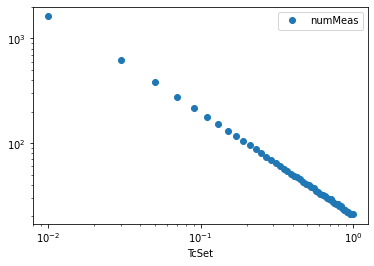

In [68]:
# sanity chec
df1.plot(x='TcSet', y='numMeas', logx=True, logy=True, style='o')

<Axes: xlabel='TcSet'>

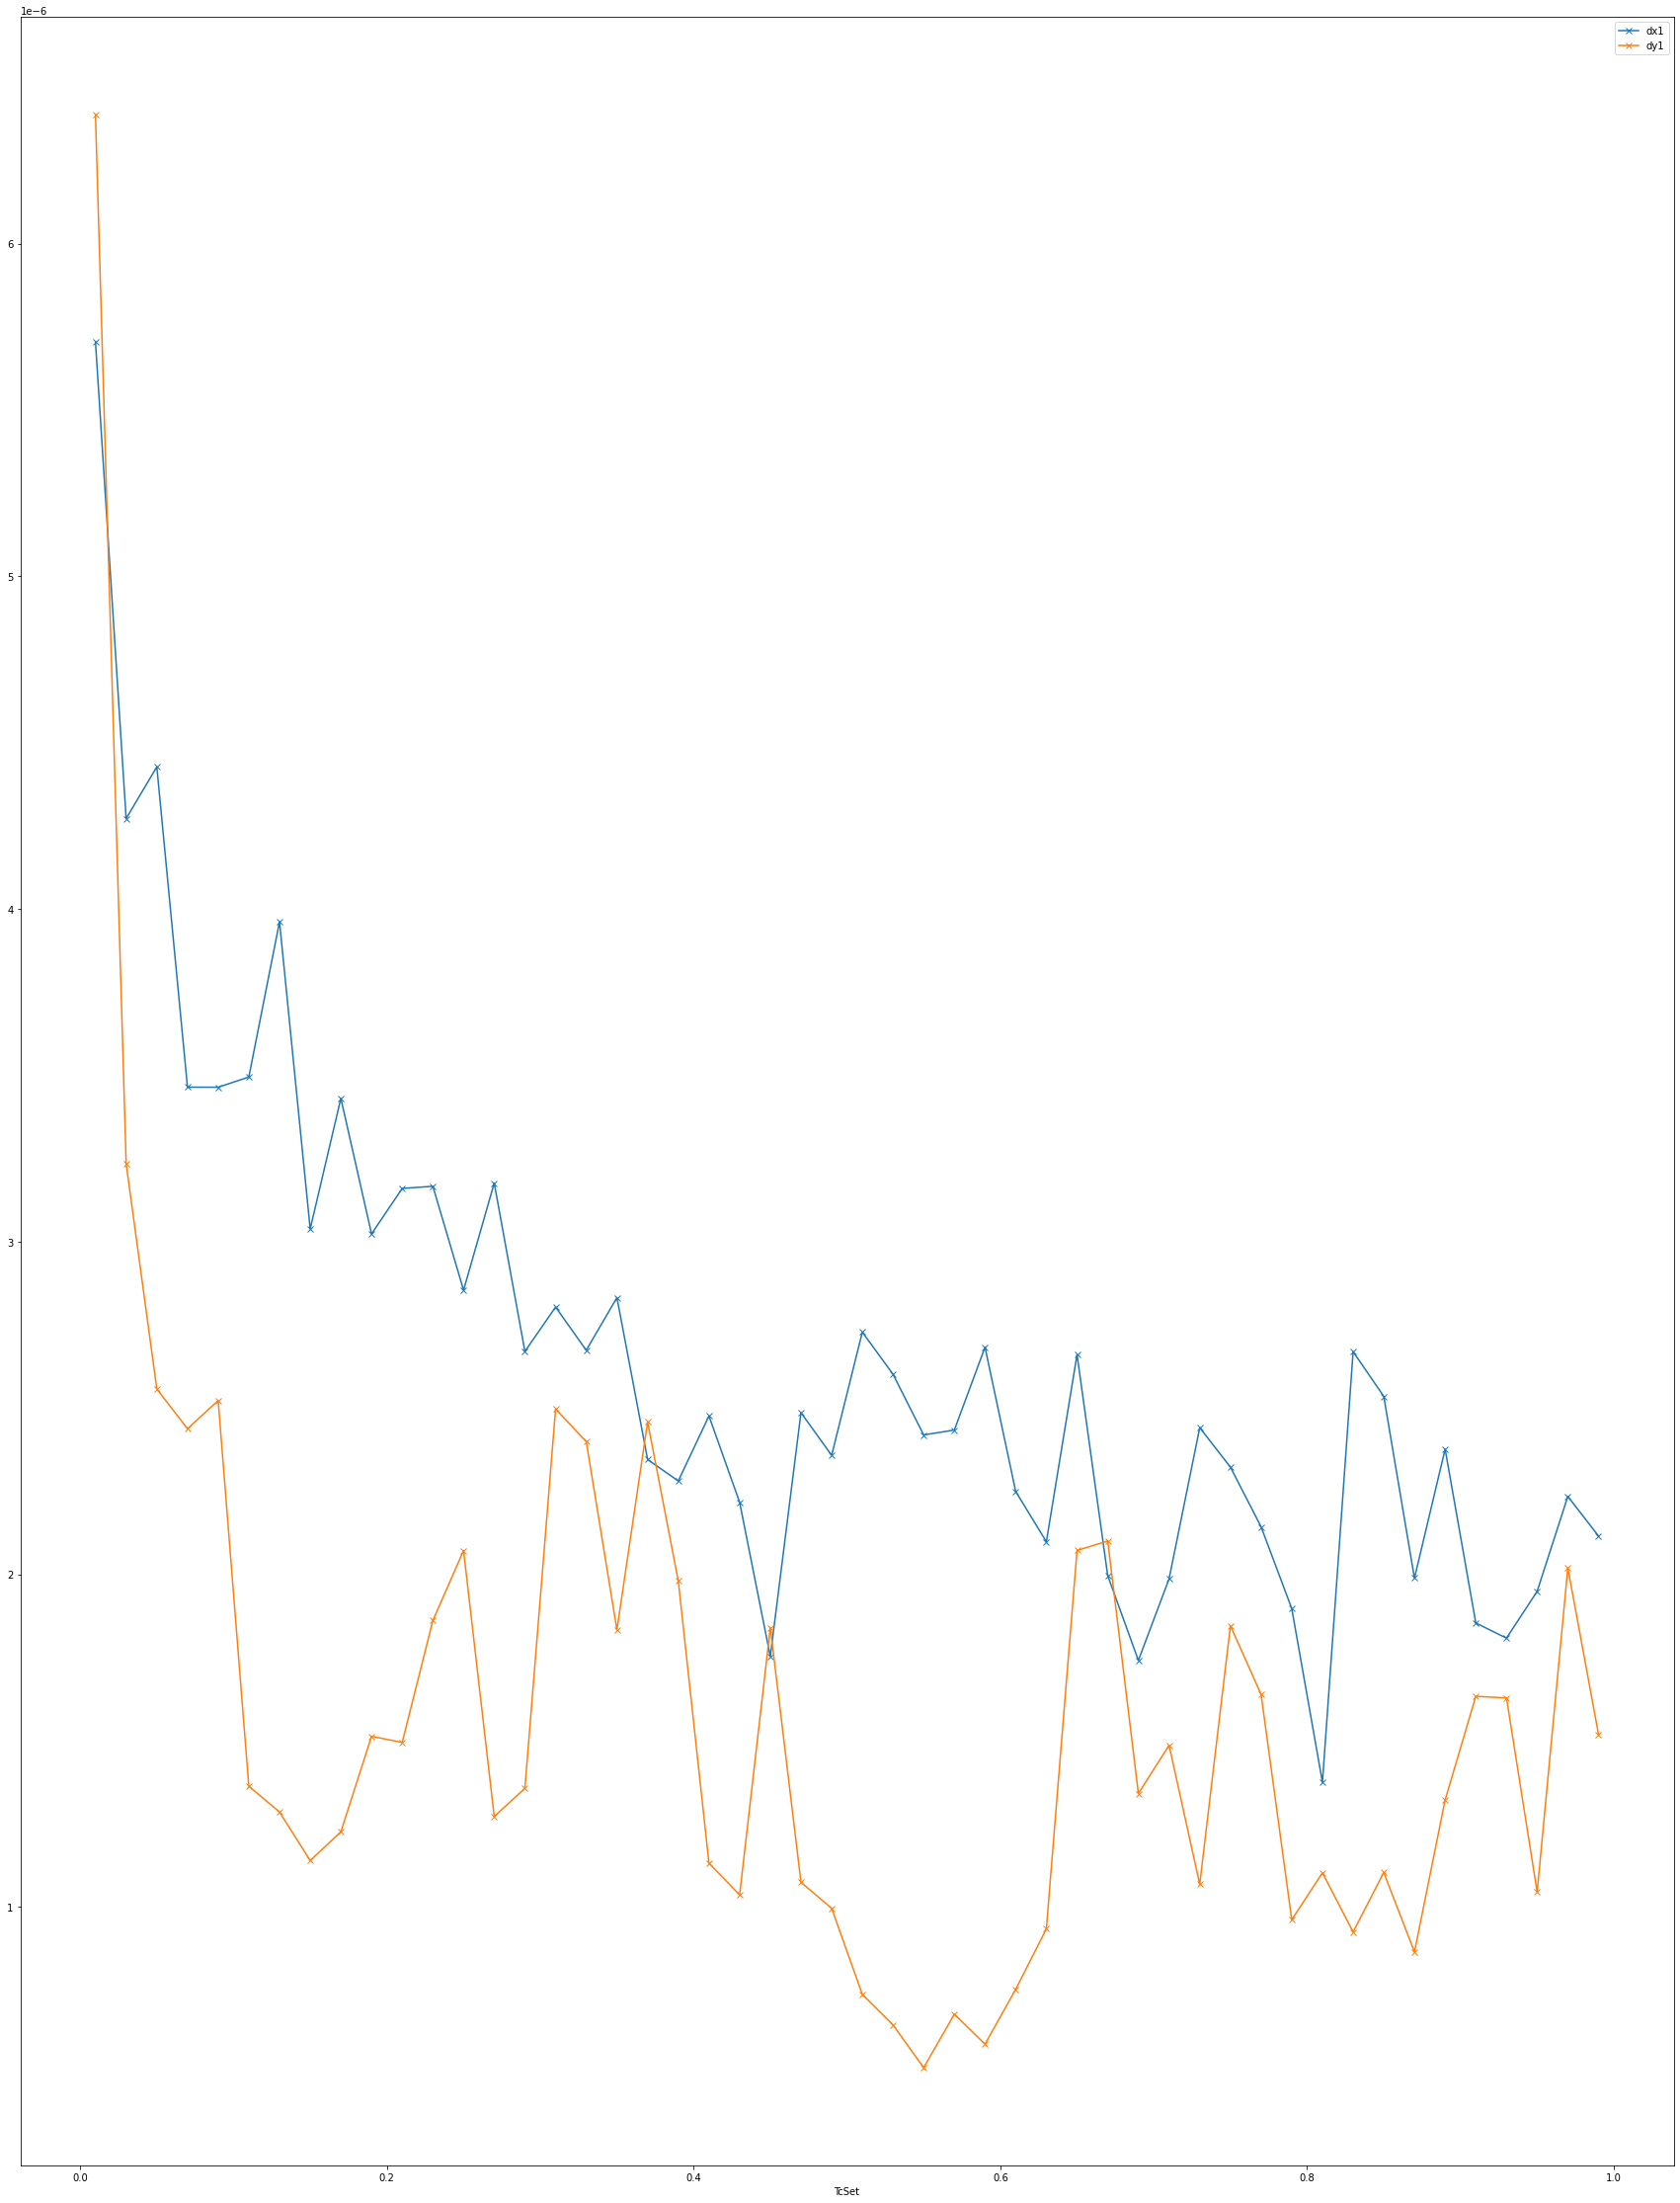

In [55]:
fig, ax = plt.subplots(1, 1)

#set dpi to 300
# fig.set_dpi(300)



# Plotting both DataFrames on the same axes
# df0.plot(x='TcSet', y=['dx1', 'dy1'], marker='x', ax=ax)
# df0.plot(x='TcSet', y=['dx1', 'dy1'], marker='x', ax=ax)
df1.plot(x='TcSet', y=['dx1', 'dy1'], marker='x', ax=ax)


# Noise Frequency Spectrum

In [71]:
Freqs =  5* 10 ** np.linspace(-1, 7, 81); Freqs
# Freqs = [
# #      5.00000000e+01, 6.29462706e+01, 7.92446596e+01, 9.97631157e+01,
# #        1.25594322e+02, 1.58113883e+02, 1.99053585e+02, 2.50593617e+02,

#        1.25594322e+04, 1.58113883e+04, 1.99053585e+04, 2.50593617e+04,
#        3.15478672e+04, 3.97164117e+04, 5.00000000e+04, 6.29462706e+04,
#        ]

array([5.00000000e-01, 6.29462706e-01, 7.92446596e-01, 9.97631157e-01,
       1.25594322e+00, 1.58113883e+00, 1.99053585e+00, 2.50593617e+00,
       3.15478672e+00, 3.97164117e+00, 5.00000000e+00, 6.29462706e+00,
       7.92446596e+00, 9.97631157e+00, 1.25594322e+01, 1.58113883e+01,
       1.99053585e+01, 2.50593617e+01, 3.15478672e+01, 3.97164117e+01,
       5.00000000e+01, 6.29462706e+01, 7.92446596e+01, 9.97631157e+01,
       1.25594322e+02, 1.58113883e+02, 1.99053585e+02, 2.50593617e+02,
       3.15478672e+02, 3.97164117e+02, 5.00000000e+02, 6.29462706e+02,
       7.92446596e+02, 9.97631157e+02, 1.25594322e+03, 1.58113883e+03,
       1.99053585e+03, 2.50593617e+03, 3.15478672e+03, 3.97164117e+03,
       5.00000000e+03, 6.29462706e+03, 7.92446596e+03, 9.97631157e+03,
       1.25594322e+04, 1.58113883e+04, 1.99053585e+04, 2.50593617e+04,
       3.15478672e+04, 3.97164117e+04, 5.00000000e+04, 6.29462706e+04,
       7.92446596e+04, 9.97631157e+04, 1.25594322e+05, 1.58113883e+05,
      

In [72]:
results = dict()
for Freq in Freqs:
    print(Freq)
    data = get_noise_data(device,  TcSet = 0.01, numSamples = 100000000000000, demod = 3, tmeasure = 10, FreqSet = Freq)
    results[Freq] = data




0.5
0.6294627058970836
0.7924465962305567
0.9976311574844399
1.25594321575479
1.5811388300841898
1.9905358527674866
2.505936168136362
3.1547867224009667
3.9716411736214075
5.0
6.294627058970837
7.92446596230557
9.976311574844399
12.559432157547905
15.811388300841898
19.905358527674867
25.059361681363622
31.547867224009668
39.716411736214084
50.0
62.94627058970838
79.24465962305571
99.76311574844404
125.5943215754791
158.11388300841895
199.05358527674866
250.59361681363626
315.47867224009684
397.16411736214104
500.0
629.4627058970838
792.4465962305571
997.6311574844403
1255.9432157547913
1581.1388300841897
1990.5358527674866
2505.9361681363625
3154.7867224009683
3971.641173621411
5000.0
6294.627058970844
7924.46596230557
9976.311574844394
12559.43215754791
15811.388300841898
19905.358527674885
25059.361681363625
31547.867224009715
39716.41173621411
50000.0
62946.27058970844
79244.6596230557
99763.11574844414
125594.32157547912
158113.88300841895
199053.58527674887
250593.61681363627
315

In [73]:
# for Freq , data in results.items():
#     print(Freq), data.x.std())

# %matplotlib

TcSet = [ data.TcSet.mean() for data in results.values()]
TcReal = [ data.TcReal.mean() for data in results.values()]
x1 = [ data.x.mean() for data in results.values()]
y1 = [ data.y.mean() for data in results.values()]
dx1 = [ data.x.std() for data in results.values()]
dy1 = [ data.y.std() for data in results.values()]

df = pd.DataFrame({'Freqs':Freqs,'TcSet': TcSet, 'TcReal': TcReal, 'x1': x1, 'y1': y1, 'dx1': dx1, 'dy1': dy1})
df["xSensitivity"] = df.dx1 * np.sqrt(df.TcReal)
df["ySensitivity"] = df.dy1 * np.sqrt(df.TcReal)


In [74]:
# df.to_csv('darkNoise_OscFreqSweep_scantime10s_Rerun_1mod60Hz_tc10ms.csv')
# results_df.to_csv('darkNoise_OscFreqSweep_scantime1000s_rawdata.csv')

In [75]:
df0 = pd.read_csv('darkNoise_OscFreqSweep_scantime1000s.csv');
df1 = pd.read_csv('darkNoise_OscFreqSweep_scantime1000s_subsetRerun.csv');
df2 = pd.read_csv('darkNoise_OscFreqSweep_scantime1000s_subsetRerun2.csv');
df3 = pd.read_csv('darkNoise_OscFreqSweep_scantime1000s_subsubsetRerun1.csv');
df4 = pd.read_csv('darkNoise_OscFreqSweep_scantime1000s_subsubsetRerun_1mod3Hz.csv');
df5 = pd.read_csv('darkNoise_OscFreqSweep_scantime1000s_subsubsetRerun_1mod60Hz_tc10ms.csv');
df6 = pd.read_csv('50ohmNoise_OscFreqSweep_scantime10s_Rerun_1mod60Hz_tc10ms.csv');


<Axes: xlabel='Freqs'>

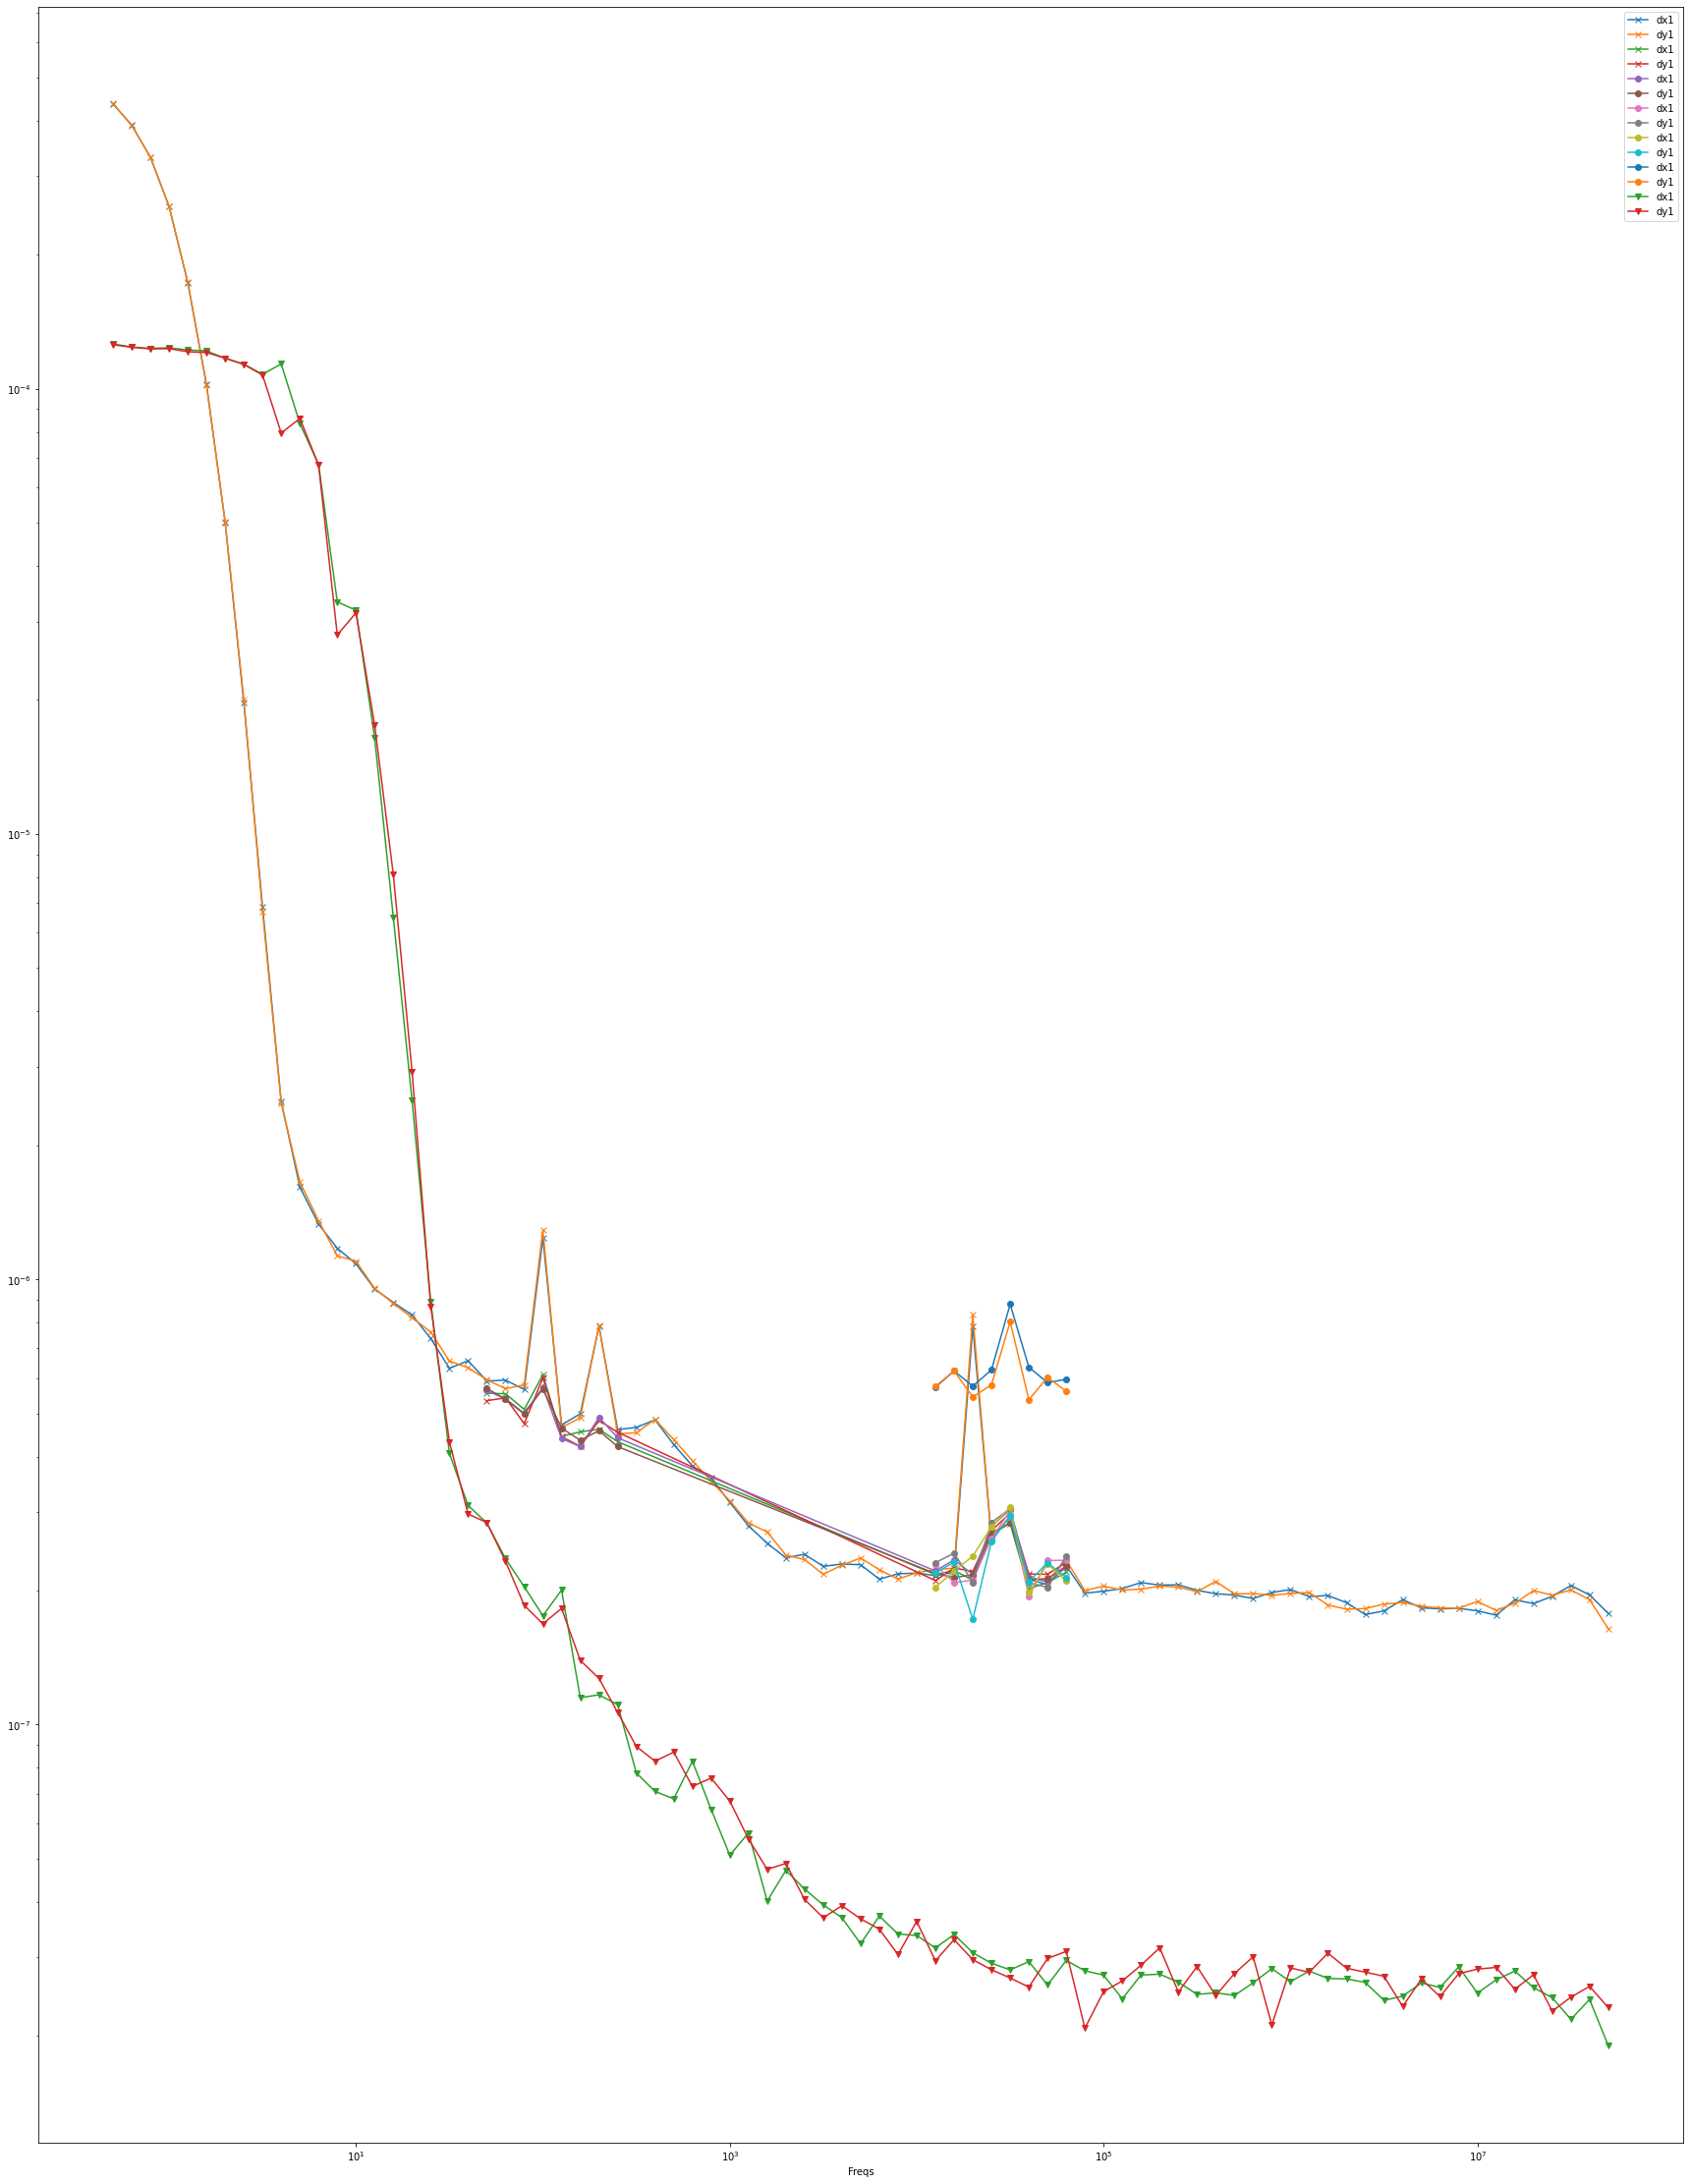

In [81]:
fig, ax = plt.subplots(1, 1, figsize=(30, 40))

#set dpi to 300
# fig.set_dpi(300)



# Plotting both DataFrames on the same axes
df0.plot(x='Freqs', y=['dx1', 'dy1'], logy=True, logx=True, marker='x', ax=ax)
df1.plot(x='Freqs', y=['dx1', 'dy1'], logy=True, logx=True, marker='x', ax=ax)
df2.plot(x='Freqs', y=['dx1', 'dy1'], logy=True, logx=True, marker='o', ax=ax)
df3.plot(x='Freqs', y=['dx1', 'dy1'], logy=True, logx=True, marker='o', ax=ax)
df4.plot(x='Freqs', y=['dx1', 'dy1'], logy=True, logx=True, marker='o', ax=ax)
df5.plot(x='Freqs', y=['dx1', 'dy1'], logy=True, logx=True, marker='o', ax=ax)
df6.plot(x='Freqs', y=['dx1', 'dy1'], logy=True, logx=True, marker='v', ax=ax) #Electronics noise




<Axes: xlabel='Freqs'>

<Figure size 432x288 with 0 Axes>

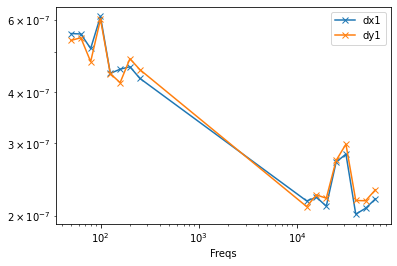

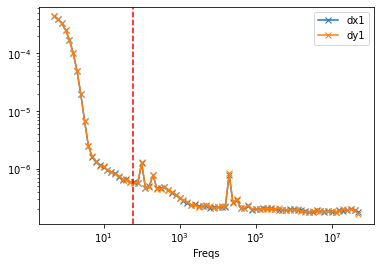

<Figure size 432x288 with 0 Axes>

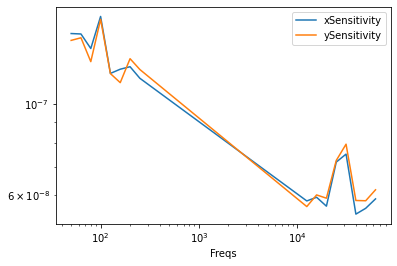

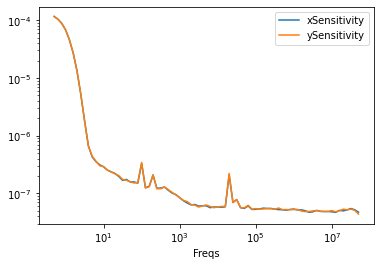

In [25]:
plt.figure()


df.plot(x='Freqs', y=['dx1','dy1'], logy=True,logx=True,marker='x')
df2.plot(x='Freqs', y=['dx1','dy1'], logy=True,logx=True,marker='x')

# vertical line at 60Hz
plt.axvline(x=60, color='r', linestyle='--')


plt.figure()
df.plot(x='Freqs', y=['xSensitivity','ySensitivity'], logy=True,logx=True)
df2.plot(x='Freqs', y=['xSensitivity','ySensitivity'], logy=True,logx=True)


In [21]:
# import pandas as pd

# # Sample DataFrames in a dictionary
# results = {
#     'experiment1': pd.DataFrame({
#         'A': [1, 2, 3],
#         'B': [4, 5, 6]
#     }),
#     'experiment2': pd.DataFrame({
#         'A': [7, 8, 9],
#         'B': [10, 11, 12]
#     })
# }

# Concatenating DataFrames including the dictionary keys as a new column
results_df = pd.concat(results.values(), keys=results.keys(), axis=0).reset_index()
# results_df.rename(columns={'level_0': 'Experiment'}, inplace=True)

# Show the DataFrame
results_df.level_0.unique()

# Uncomment the below line when finalizing the code
# results_df


array([5.00000000e-01, 6.29462706e-01, 7.92446596e-01, 9.97631157e-01,
       1.25594322e+00, 1.58113883e+00, 1.99053585e+00, 2.50593617e+00,
       3.15478672e+00, 3.97164117e+00, 5.00000000e+00, 6.29462706e+00,
       7.92446596e+00, 9.97631157e+00, 1.25594322e+01, 1.58113883e+01,
       1.99053585e+01, 2.50593617e+01, 3.15478672e+01, 3.97164117e+01,
       5.00000000e+01, 6.29462706e+01, 7.92446596e+01, 9.97631157e+01,
       1.25594322e+02, 1.58113883e+02, 1.99053585e+02, 2.50593617e+02,
       3.15478672e+02, 3.97164117e+02, 5.00000000e+02, 6.29462706e+02,
       7.92446596e+02, 9.97631157e+02, 1.25594322e+03, 1.58113883e+03,
       1.99053585e+03, 2.50593617e+03, 3.15478672e+03, 3.97164117e+03,
       5.00000000e+03, 6.29462706e+03, 7.92446596e+03, 9.97631157e+03,
       1.25594322e+04, 1.58113883e+04, 1.99053585e+04, 2.50593617e+04,
       3.15478672e+04, 3.97164117e+04, 5.00000000e+04, 6.29462706e+04,
       7.92446596e+04, 9.97631157e+04, 1.25594322e+05, 1.58113883e+05,
      